In [3]:
import os
from openai import OpenAI
import gradio as gr
import json
from dotenv import load_dotenv
import requests

c:\Users\dell\Desktop\llmEngineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
tools = [
    {
        "type":"function",
        "function": {  
            "name": "get_horoscope",
            "description": "Get the daily horoscope for a specific zodiac sign.",
            "parameters": {
                "type": "object",
                "properties": {
                    "sign": {
                        "type": "string",
                        "description": "The zodiac sign of the user, e.g., Aries, Leo, Capricorn."
                    }
                },
                "required": ["sign"],
                "additionalProperties": False 
            },
            "strict": True
        }

    }
]

In [105]:
url = "https://astropredict-daily-horoscopes-lucky-insights.p.rapidapi.com/horoscope"



headers = {
	"x-rapidapi-key": "8a75c35cd3msh47bea06b172383ep17e501jsn190ac1c2224e",
	"x-rapidapi-host": "astropredict-daily-horoscopes-lucky-insights.p.rapidapi.com",
	"Content-Type": "application/json"
}

In [6]:
def get_horoscope(sign):
    querystring = {"lang":"en","zodiac":sign,"type":"daily","timezone":"UTC"}
    response = requests.get(url, headers=headers, params=querystring)
    result = response.json()
    return result.get("horoscope")

In [7]:
get_horoscope("libra")

'Making someone smile again can make a huge difference to that person. You have all the keys you need right in your pocket. Ideas are flowing and come with ease. Reaffirm what you want and then go for it. Enjoy some time away from the everyday routine.'

In [8]:
system_message = """You are a helpful assistant. You have a specific expertise in horoscopes.

STRICT TOOL RULES:
1. Do NOT call the horoscope tool for general greetings (e.g., 'Hello', 'How are you?').
2. Do NOT call the tool for general life advice unless the user explicitly mentions their zodiac sign or asks for a 'prediction' or 'horoscope'.
3. If a user is just chatting, respond with text only.
4. ONLY trigger the tool if the intent is clearly to receive a formal astrological reading."""

In [102]:
def handle_tool_call(message):
    tool_call = message.tool_calls[0]
    if tool_call.function.name == "get_horoscope":
        arguments = json.loads(tool_call.function.arguments)
        sign = arguments.get('sign')
        is_image = True
        horoscope = get_horoscope(sign)
        result = {
            "role": "tool",
            "content": horoscope,
            "tool_call_id": tool_call.id
        }
        return result,True
    return None,False

In [103]:
client = OpenAI()

def chat(message,history):
    messages1 = []
    history = [{"role":h["role"], "content":h["content"]} for h in history]

    messages = [{"role":"system","content":system_message}] + history + [{"role":"user","content":message}]
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        tools = tools
    )
    is_image = False
    if response.choices[0].finish_reason=="tool_calls":
        msg = response.choices[0].message
        response = handle_tool_call(msg,is_image)
        messages.append(msg)
        messages.append(response)
        response = client.chat.completions.create(model="gpt-4.1-nano", messages=messages)
    
    



        


In [104]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7880
* To create a public link, set `share=True` in `launch()`.


In [32]:
import base64
from io import BytesIO
from PIL import  Image

In [43]:
def image_display(prompt):
    result = client.images.generate(
    model="dall-e-3",
    prompt=prompt,
    size="1024x1024",
    n=1,
     response_format="b64_json",
    )

    image_base64 = result.data[0].b64_json
    image_bytes = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_bytes))

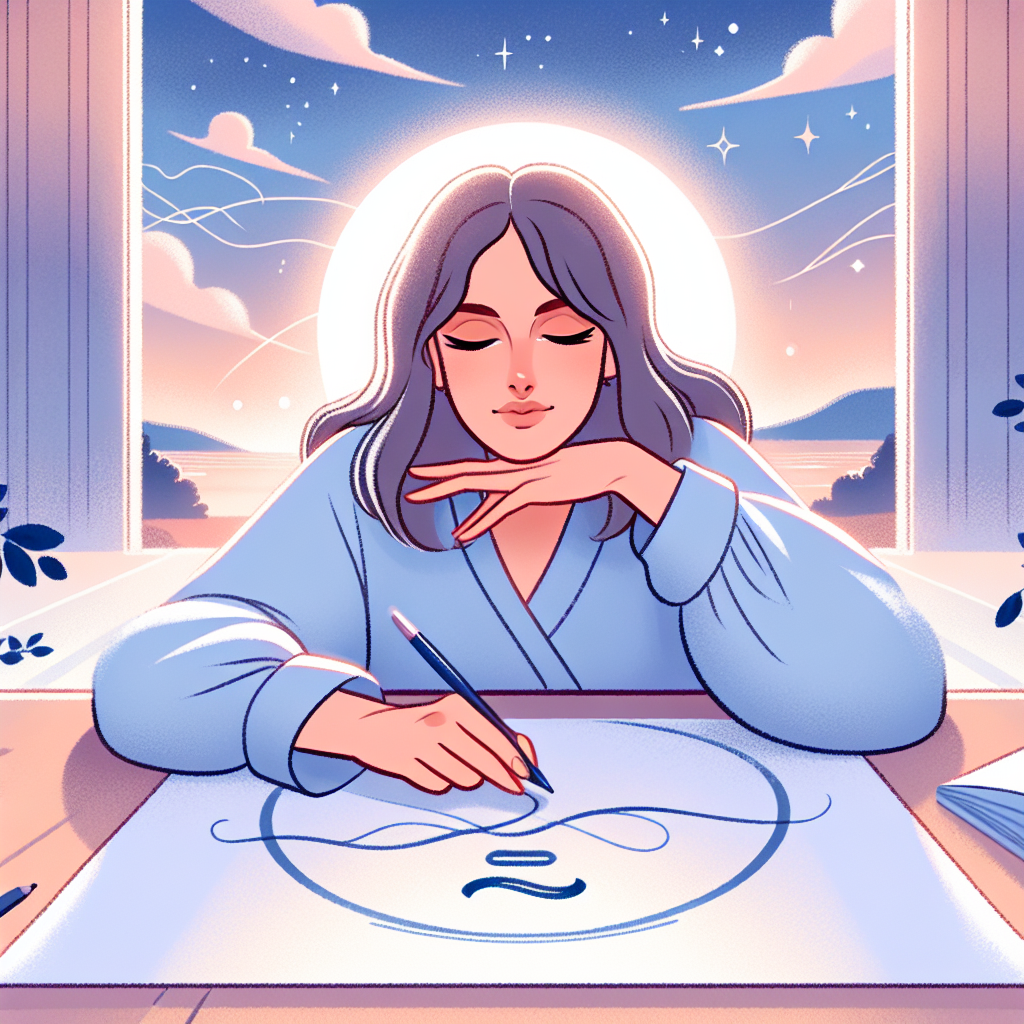

In [44]:
image_display("Today, as a Libra, you will find peace and tranquility by taking some time away from your daily routine. Opportunities for compromise will help you find the right path forward. Your ideas are flowing easily, so trust your intuition. Stay calm and confident, and things are likely to unfold smoothly.")

In [69]:
def talker(message):
    response = client.audio.speech.create(
    model="gpt-4o-mini-tts",
    voice="coral",    # Also, try replacing onyx with alloy or coral
    input=message
    )
    return response.content

In [108]:
def chat(message,history):
    if history is None:
        history = []
    messages1 = []
    history = [{"role":h["role"], "content":h["content"]} for h in history]

    messages = [{"role":"system","content":system_message}] + history + [{"role":"user","content":message}]
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        tools = tools
    )
    is_image = False
    if response.choices[0].finish_reason=="tool_calls":
        msg = response.choices[0].message
        response,is_image = handle_tool_call(msg)
        if response : 
            messages.append(msg)
            messages.append(response)
            response = client.chat.completions.create(model="gpt-4.1-nano", messages=messages)
    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)
    image = image_display(reply)  if is_image else None
    
    
    return reply, voice, image
    

In [109]:
chat("hey",None)

("I'm here to help! If you have any questions or need information about horoscopes, feel free to ask.",
 b'\xff\xf3\xc4\xc4\x00YL9\xbc\x01Yx\x00>\xf38\xcfBq\xa0\xe1\xc5\x11\xbc\xb1\x9cA\x881\x98q\xbe\xd9\xb2\xa9\xa2i\x92I\x92I\x92Y\x96Y\x92884\x14HB\xee\x16\x90\xb4\x85\xc8@"\x01\x10p\x01X\x0b`C\x0389\xc3V\x1a\xb0\xd5\x84\x8c\x08\x00\xa8\t\x00\x86\t\xa0\x9a\t\xa0\x9a\x08`*\xc2F!\xe2n&\xe2n&\xe2\xe6B\xc7\xa0z\x07\xa0z\x07\xa0z\x07\xa0z\x07\xa0M\xc5\xccz\xc7\xacz\xc7\xacz\xc8Ys.\x06\x81\xa0[\t\xc0\xf4\x0b`\x9a\x0b\x80\xb9\x8fX\xf5\x90\xb2vN\xc9\xd9;!bh&\x83\xd0B\t\xc1\xa0h\x1a\x06\x81;\'e\xcc\xd34\xcd3L\xd34\xc9\xc1p4\r\x03@\x9c\x13\x81\xe8\x17\x00\x91\x88x\xb9\x973\xad\x0fC\xcesL\x9c\x13\x82pN\t\xc184\x0e\x85\x02\x8d^\x9fC\xd0\xf4=\x0fC\xd4hb\x18h\x1a\x04\xe0\x9c\x13\x83@\xe8:\xd0\xf3\x9c\xd34\xcd3L\xd34\xc9\xc1\x04\x16\xc14\x1e\x82\xe0\xa8\x95\x0f!\x04\xe0\xd0PM\r^\xcf\x1f8`V!\x8a\xc6J\xb1\x9a\x07C&\xaf\r\xfa\xbd\x0f4\r\x02pN\t\xc184\x10\xc5c;\x1a}\x0fC\xd0\xf4=\x0fQ\xa1\x88b\x18r\x1a\x

In [114]:
def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]
with gr.Blocks() as ui:
    
    gr.Markdown("## 🤖 HoRoScOpE AI")

    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=500)

        with gr.Column(scale=2):
            image_output = gr.Image(height=250)
            audio_output = gr.Audio(autoplay=True)

    with gr.Row():
        message = gr.Textbox(
            label="",
            placeholder="Type your message and press Enter...",
            container=True
        )

    # Step 1: add user message
    def put_message_in_chatbot(message, history):
        if history is None:
            history = []
        history.append({"role": "user", "content": message})
        return "", history

    # Step 2: call your chat function
    def bot_response(history):
        if history is None:
            history = []

        user_message = history[-1]["content"]

        reply, voice, image = chat(user_message, history)

        history.append({"role": "assistant", "content": reply})

        return history, voice, image

    message.submit(
        put_message_in_chatbot,
        inputs=[message, chatbot],
        outputs=[message, chatbot]
    ).then(
        bot_response,
        inputs=[chatbot],
        outputs=[chatbot, audio_output, image_output]
    )

In [ ]:
ui.launch(share=True)

* Running on local URL:  http://127.0.0.1:7884
* Running on public URL: https://4dfdc159d6fd57a315.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Exception in callback _ProactorBasePipeTransport._call_connection_lost(None)
handle: <Handle _ProactorBasePipeTransport._call_connection_lost(None)>
Traceback (most recent call last):
  File "C:\Users\dell\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "C:\Users\dell\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\asyncio\proactor_events.py", line 165, in _call_connection_lost
    self._sock.shutdown(socket.SHUT_RDWR)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback _ProactorBasePipeTransport._call_connection_lost(None)
handle: <Handle _ProactorBasePipeTransport._call_connection_lost(None)>
Traceback (most recent call last):
  File "C:\Users\dell\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._